Dataset loaded successfully
Dataset shape: (569, 30)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimensio

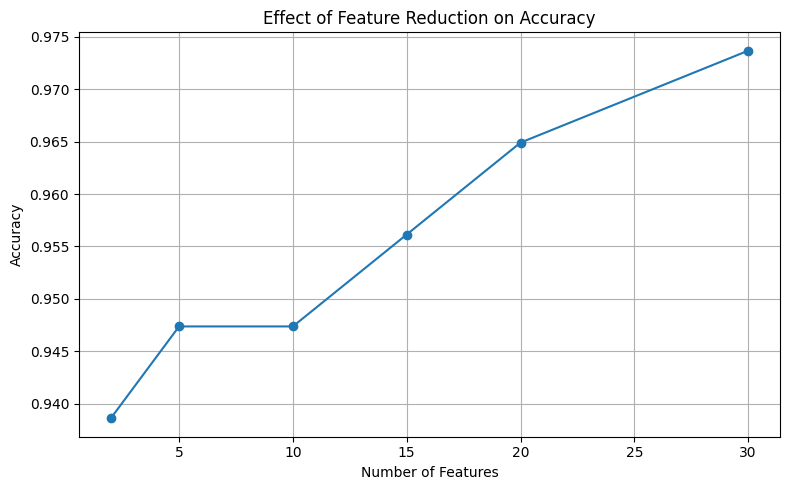

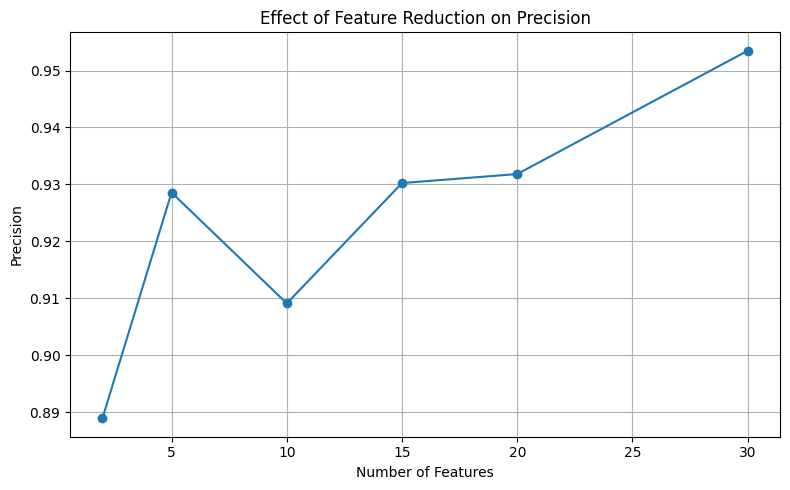

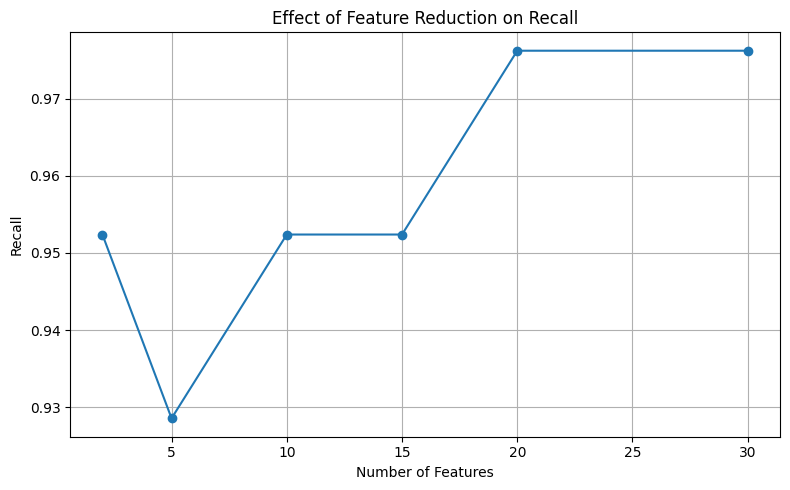

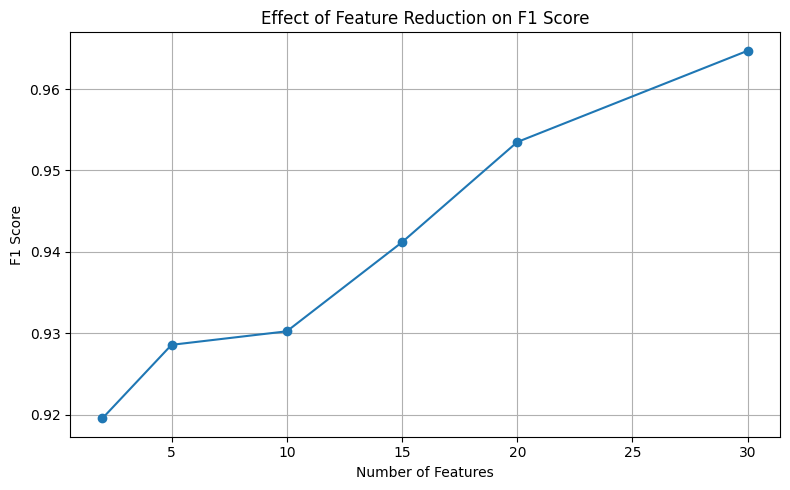

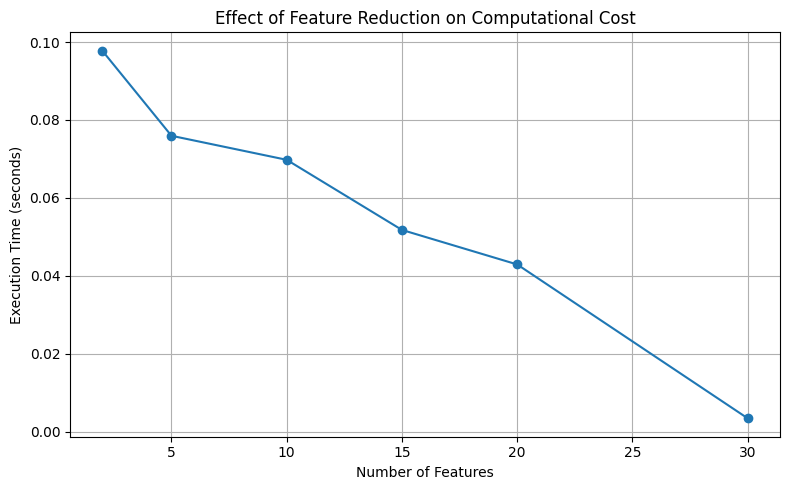

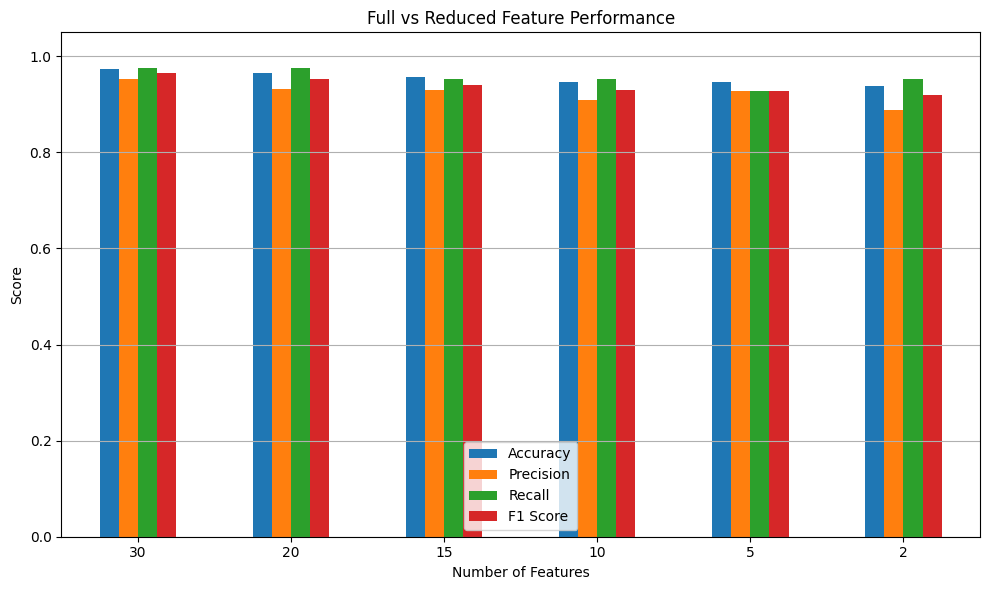

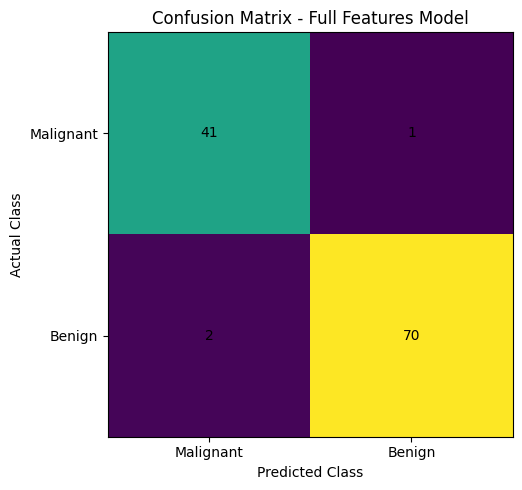


Classification Report - Full Model
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


MODEL WITH HIGHEST TEST ACCURACY
Model: Full Features
Number of features: 30
Accuracy: 0.9737
Precision: 0.9535
Recall: 0.9762
F1 Score: 0.9647
Execution Time: 0.0034 seconds

RESEARCH COMPLETED
Dataset: Breast Cancer Wisconsin
Model: Support Vector Machine
Feature Selection: RFE

Feature counts tested:
[30, 20, 15, 10, 5, 2]

All experiments completed successfully.


In [1]:

# =========================================================
# DIMENSIONALITY REDUCTION AND BREAST CANCER CLASSIFICATION
# Full Features vs Reduced Features
# Model: Support Vector Machine (SVM)
# Dataset: Breast Cancer Wisconsin Diagnostic
# =========================================================

# 1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import RFE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================================================
# 2. Load Dataset
# =========================================================

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print("Dataset loaded successfully")
print("Dataset shape:", X.shape)

print("\nFirst 5 rows:")
print(X.head())

print("\nTarget classes:")
print(data.target_names)

print("\nNumber of features:", X.shape[1])

# =========================================================
# 3. Split Dataset into Training and Testing
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# =========================================================
# 4. Standardize Features
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature standardization completed")

# =========================================================
# 5. FULL FEATURES MODEL - 30 FEATURES
# =========================================================

print("\n====================================")
print("FULL FEATURES MODEL - 30 FEATURES")
print("====================================")

start_full = time.time()

full_model = SVC(
    kernel="linear",
    random_state=42
)

full_model.fit(
    X_train_scaled,
    y_train
)

full_pred = full_model.predict(
    X_test_scaled
)

full_time = time.time() - start_full

full_accuracy = accuracy_score(
    y_test, full_pred
)

full_precision = precision_score(
    y_test, full_pred, pos_label=0
)

full_recall = recall_score(
    y_test, full_pred, pos_label=0
)

full_f1 = f1_score(
    y_test, full_pred, pos_label=0
)

print("Number of features:", X_train.shape[1])
print("Accuracy:", round(full_accuracy, 4))
print("Precision:", round(full_precision, 4))
print("Recall:", round(full_recall, 4))
print("F1 Score:", round(full_f1, 4))
print("Training Time:", round(full_time, 4), "seconds")

# Store baseline results

results = []

results.append({
    "Model": "Full Features",
    "Features": 30,
    "Accuracy": full_accuracy,
    "Precision": full_precision,
    "Recall": full_recall,
    "F1 Score": full_f1,
    "Time (seconds)": full_time
})

# =========================================================
# 6. REDUCED FEATURES MODEL
# =========================================================

print("\n====================================")
print("REDUCED FEATURES MODEL")
print("====================================")

feature_counts = [20, 15, 10, 5, 2]

selected_features_dict = {}

for n in feature_counts:

    print("\n------------------------------------")
    print("Using", n, "features")
    print("------------------------------------")

    start = time.time()

    # Select features using RFE
    selector = RFE(
        estimator=SVC(
            kernel="linear",
            random_state=42
        ),
        n_features_to_select=n,
        step=1
    )

    # Fit feature selector using training data only
    X_train_reduced = selector.fit_transform(
        X_train_scaled,
        y_train
    )

    # Apply selected features to test data
    X_test_reduced = selector.transform(
        X_test_scaled
    )

    # Train SVM on reduced features
    reduced_model = SVC(
        kernel="linear",
        random_state=42
    )

    reduced_model.fit(
        X_train_reduced,
        y_train
    )

    # Predict test data
    reduced_pred = reduced_model.predict(
        X_test_reduced
    )

    # Calculate evaluation metrics
    accuracy = accuracy_score(
        y_test, reduced_pred
    )

    precision = precision_score(
        y_test, reduced_pred, pos_label=0
    )

    recall = recall_score(
        y_test, reduced_pred, pos_label=0
    )

    f1 = f1_score(
        y_test, reduced_pred, pos_label=0
    )

    total_time = time.time() - start

    # Get selected feature names
    selected_features = list(
        X.columns[selector.support_]
    )

    selected_features_dict[n] = selected_features

    print("Selected Features:")
    print(selected_features)

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("Total Time:", round(total_time, 4), "seconds")

    # Store results
    results.append({
        "Model": "Reduced Features",
        "Features": n,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Time (seconds)": total_time
    })

# =========================================================
# 7. DISPLAY COMPARISON TABLE
# =========================================================

results_df = pd.DataFrame(results)

print("\n====================================")
print("FULL VS REDUCED FEATURES COMPARISON")
print("====================================")

print(
    results_df.round(4).to_string(index=False)
)

# =========================================================
# 8. GRAPH: NUMBER OF FEATURES VS ACCURACY
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Features"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Reduction on Accuracy")

plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 9. GRAPH: NUMBER OF FEATURES VS PRECISION
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Features"],
    results_df["Precision"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Precision")
plt.title("Effect of Feature Reduction on Precision")

plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 10. GRAPH: NUMBER OF FEATURES VS RECALL
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Features"],
    results_df["Recall"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Recall")
plt.title("Effect of Feature Reduction on Recall")

plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 11. GRAPH: NUMBER OF FEATURES VS F1 SCORE
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Features"],
    results_df["F1 Score"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("F1 Score")
plt.title("Effect of Feature Reduction on F1 Score")

plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 12. GRAPH: FEATURES VS COMPUTATIONAL COST
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Features"],
    results_df["Time (seconds)"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Execution Time (seconds)")
plt.title("Effect of Feature Reduction on Computational Cost")

plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 13. PERFORMANCE COMPARISON BAR CHART
# =========================================================

results_df.set_index("Features")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Full vs Reduced Feature Performance")
plt.xlabel("Number of Features")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# =========================================================
# 14. CONFUSION MATRIX FOR FULL FEATURES MODEL
# =========================================================

cm = confusion_matrix(
    y_test,
    full_pred,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Full Features Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.yticks(
    [0, 1],
    ["Malignant", "Benign"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

print("\nClassification Report - Full Model")

print(
    classification_report(
        y_test,
        full_pred,
        target_names=data.target_names
    )
)

# =========================================================
# 15. FIND MODEL WITH HIGHEST ACCURACY
# =========================================================

best_index = results_df["Accuracy"].idxmax()

best_result = results_df.loc[best_index]

print("\n====================================")
print("MODEL WITH HIGHEST TEST ACCURACY")
print("====================================")

print("Model:", best_result["Model"])

print(
    "Number of features:",
    int(best_result["Features"])
)

print(
    "Accuracy:",
    round(best_result["Accuracy"], 4)
)

print(
    "Precision:",
    round(best_result["Precision"], 4)
)

print(
    "Recall:",
    round(best_result["Recall"], 4)
)

print(
    "F1 Score:",
    round(best_result["F1 Score"], 4)
)

print(
    "Execution Time:",
    round(best_result["Time (seconds)"], 4),
    "seconds"
)

# =========================================================
# 16. FINAL RESEARCH SUMMARY
# =========================================================

print("\n====================================")
print("RESEARCH COMPLETED")
print("====================================")

print("Dataset: Breast Cancer Wisconsin")
print("Model: Support Vector Machine")
print("Feature Selection: RFE")

print("\nFeature counts tested:")
print([30] + feature_counts)

print("\nAll experiments completed successfully.")